Randomly samples from historical weekly points (with replacement)

Average Final Points (Simulated): 197.7234


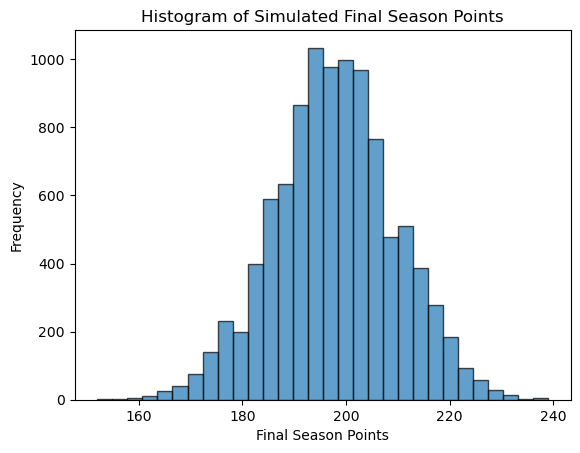

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Historical weekly points from two seasons
ryan_2016_17 = [11, 5, 11, 11, 6, 13, 5, 15, 20, 10,
                15, 10, 14, 11, 8, 9, 18, 15, 18, 20]
ryan_2017_18 = [14, 6, 12, 11, 13, 11, 9, 12, 1, 18,
                9, 14, 15, 14, 11, 6, 11, 11, 10, 15]

# Combine the historical data into one list for resampling
historical_weekly_points = ryan_2016_17 + ryan_2017_18

# Current season (2018-19) data: points from Matchups 1-12
ryan_2018_19_so_far = [0, 8, 5, 7, 3, 9, 11, 12, 9, 11, 10, 19]
current_points = sum(ryan_2018_19_so_far)  # 104 points so far

# There are 20 matchups total; remaining matchups = 20 - 12 = 8
remaining_matchups = 8

# Number of simulation runs (trials)
num_simulations = 10000

# List to store simulated final season points
simulated_final_points = []

# Bootstrap simulation:
for _ in range(num_simulations):
    # For each simulation, randomly sample points for the remaining 8 matchups (with replacement)
    future_points = [random.choice(historical_weekly_points) for _ in range(remaining_matchups)]
    total_future_points = sum(future_points)
    
    # Compute the simulated final season total
    final_points = current_points + total_future_points
    simulated_final_points.append(final_points)

# Compute and display the average simulated final points
average_final = np.mean(simulated_final_points)
print("Average Final Points (Simulated):", average_final)

# Plot a histogram of the simulated final points distribution
plt.hist(simulated_final_points, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Final Season Points")
plt.ylabel("Frequency")
plt.title("Histogram of Simulated Final Season Points")
plt.show()


season 17 - 18  give more importance 

[11, 5, 11, 11, 6, 13, 5, 15, 20, 10, 15, 10, 14, 11, 8, 9, 18, 15, 18, 20, 14, 6, 12, 11, 13, 11, 9, 12, 1, 18, 9, 14, 15, 14, 11, 6, 11, 11, 10, 15, 14, 6, 12, 11, 13, 11, 9, 12, 1, 18, 9, 14, 15, 14, 11, 6, 11, 11, 10, 15, 14, 6, 12, 11, 13, 11, 9, 12, 1, 18, 9, 14, 15, 14, 11, 6, 11, 11, 10, 15]
Average Final Points (Simulated): 195.2975


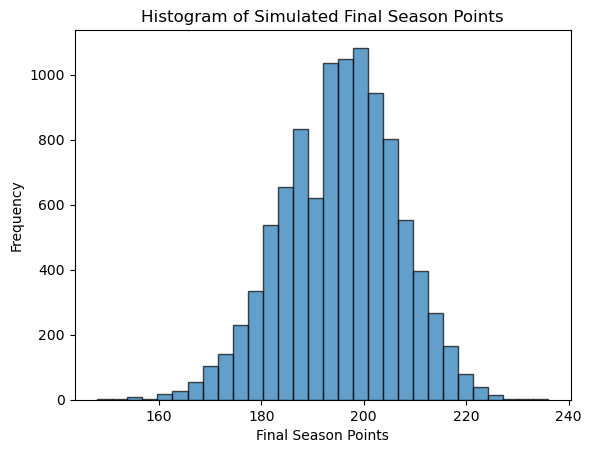

In [33]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Historical weekly points from two seasons
ryan_2016_17 = [11, 5, 11, 11, 6, 13, 5, 15, 20, 10,
                15, 10, 14, 11, 8, 9, 18, 15, 18, 20]
ryan_2017_18 = [14, 6, 12, 11, 13, 11, 9, 12, 1, 18,
                9, 14, 15, 14, 11, 6, 11, 11, 10, 15]

# Combine the historical data into one list for resampling
historical_weekly_points = ryan_2016_17 + ryan_2017_18*3
print(historical_weekly_points)
# Current season (2018-19) data: points from Matchups 1-12
ryan_2018_19_so_far = [0, 8, 5, 7, 3, 9, 11, 12, 9, 11, 10, 19]
current_points = sum(ryan_2018_19_so_far)  # 104 points so far

# There are 20 matchups total; remaining matchups = 20 - 12 = 8
remaining_matchups = 8

# Number of simulation runs (trials)
num_simulations = 10000

# List to store simulated final season points
simulated_final_points = []

# Bootstrap simulation:
for _ in range(num_simulations):
    # For each simulation, randomly sample points for the remaining 8 matchups (with replacement)
    future_points = [random.choice(historical_weekly_points) for _ in range(remaining_matchups)]
    total_future_points = sum(future_points)
    
    # Compute the simulated final season total
    final_points = current_points + total_future_points
    simulated_final_points.append(final_points)

# Compute and display the average simulated final points
average_final = np.mean(simulated_final_points)
print("Average Final Points (Simulated):", average_final)

# Plot a histogram of the simulated final points distribution
plt.hist(simulated_final_points, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Final Season Points")
plt.ylabel("Frequency")
plt.title("Histogram of Simulated Final Season Points")
plt.show()


Generates future points using a fitted normal distribution

Normal Distribution 

✅ Advantage: Captures underlying performance trends using mean and standard deviation.
✅ Advantage: Allows for natural randomness, including some unseen values.
❌ Disadvantage: Assumes performance follows a normal distribution, which may not be the best fit.

Fitted Normal Distribution: Mean = 11.7 Std Dev = 4.1952353926806065


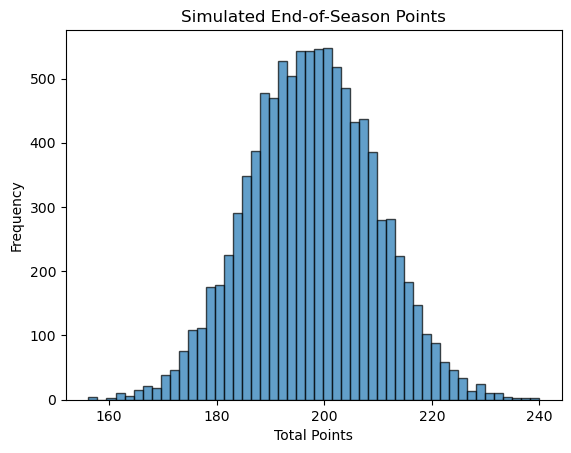

Average Simulated Final Points: 197.6988934401993


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Historical weekly points (from 2016-17 and 2017-18)
ryan_2016_17 = [11, 5, 11, 11, 6, 13, 5, 15, 20, 10,
                15, 10, 14, 11, 8, 9, 18, 15, 18, 20]
ryan_2017_18 = [14, 6, 12, 11, 13, 11, 9, 12, 1, 18,
                9, 14, 15, 14, 11, 6, 11, 11, 10, 15]

# Combine historical data
historical_weekly = ryan_2016_17 + ryan_2017_18

# Fit a normal distribution
mu = np.mean(historical_weekly)
sigma = np.std(historical_weekly, ddof=1)
print("Fitted Normal Distribution: Mean =", mu, "Std Dev =", sigma)

# Given current season data:
current_points = 104  # points from matchups 1-12
remaining_matchups = 8

# Simulation parameters
N = 10000  # number of simulated seasons
simulated_totals = []

for _ in range(N):
    # Generate points for 8 matchups from the fitted normal distribution
    simulated_future = np.random.normal(mu, sigma, remaining_matchups)
    # Replace any negative values with 0 (since negative points don't make sense)
    simulated_future = [max(0, x) for x in simulated_future]
    season_total = current_points + sum(simulated_future)
    simulated_totals.append(season_total)

# Plot histogram of simulated end-of-season totals
plt.hist(simulated_totals, bins=50, edgecolor='k', alpha=0.7)
plt.title("Simulated End-of-Season Points")
plt.xlabel("Total Points")
plt.ylabel("Frequency")
plt.show()

# Compute average and other statistics if needed
average_total = np.mean(simulated_totals)
print("Average Simulated Final Points:", average_total)


bootstap :  median, standard deviation, 10th & 90th percentiles

Average Final Points: 197.56
Median Final Points: 198.00
Standard Deviation: 11.76
10th Percentile: 182.00
90th Percentile: 213.00


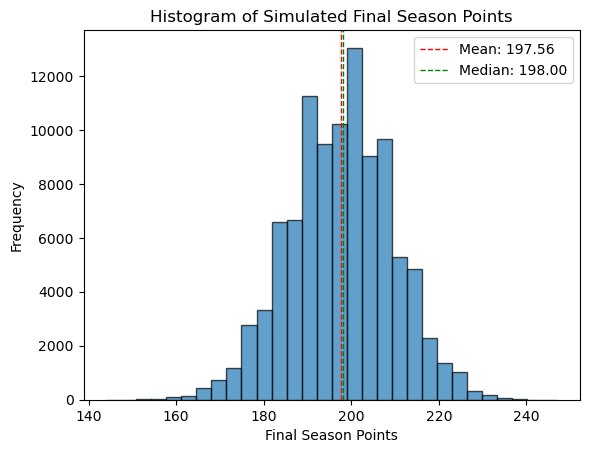

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Historical weekly points from two seasons
ryan_2016_17 = [11, 5, 11, 11, 6, 13, 5, 15, 20, 10,
                15, 10, 14, 11, 8, 9, 18, 15, 18, 20]
ryan_2017_18 = [14, 6, 12, 11, 13, 11, 9, 12, 1, 18,
                9, 14, 15, 14, 11, 6, 11, 11, 10, 15]

# Combine the historical data into one list
historical_weekly_points = ryan_2016_17 + ryan_2017_18

# Current season data (matchups 1-12)
ryan_2018_19_so_far = [0, 8, 5, 7, 3, 9, 11, 12, 9, 11, 10, 19]
current_points = sum(ryan_2018_19_so_far)  # 104 points

remaining_matchups = 8
num_simulations = 100000
simulated_totals = []

for _ in range(num_simulations):
    future_points = [random.choice(historical_weekly_points) for _ in range(remaining_matchups)]
    final_points = current_points + sum(future_points)
    simulated_totals.append(final_points)

# Convert to numpy array for analysis
simulated_totals = np.array(simulated_totals)

# Calculate metrics
mean_final = np.mean(simulated_totals)
median_final = np.median(simulated_totals)
std_final = np.std(simulated_totals, ddof=1)
percentile_10 = np.percentile(simulated_totals, 10)
percentile_90 = np.percentile(simulated_totals, 90)

print(f"Average Final Points: {mean_final:.2f}")
print(f"Median Final Points: {median_final:.2f}")
print(f"Standard Deviation: {std_final:.2f}")
print(f"10th Percentile: {percentile_10:.2f}")
print(f"90th Percentile: {percentile_90:.2f}")

# Plot histogram
plt.hist(simulated_totals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Final Season Points")
plt.ylabel("Frequency")
plt.title("Histogram of Simulated Final Season Points")
plt.axvline(mean_final, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_final:.2f}')
plt.axvline(median_final, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_final:.2f}')
plt.legend()
plt.show()


Simulates the 8th place cutoff for both seasons (2016-17 and 2017-18) using resampling.
Compares Ryan’s simulated final points against the 8th place distribution

In [5]:
import numpy as np
import random

# Given historical final season points (Exhibit 3)
season_2016_17 = [245, 238, 225, 220, 208, 207, 204, 189, 188, 162, 159, 155]
season_2017_18 = [282, 262, 223, 217, 201, 198, 190, 190, 173, 170, 166, 128]

# Number of simulations
num_simulations = 10000

# Simulated 8th place points storage
simulated_8th_place_points_2016 = []
simulated_8th_place_points_2017 = []

# Simulate 8th place points for 2016-17
for _ in range(num_simulations):
    sampled_season = random.choices(season_2016_17, k=len(season_2016_17))  # Resample entire season
    sampled_season.sort(reverse=True)  # Rank teams
    simulated_8th_place_points_2016.append(sampled_season[7])  # Store 8th place

# Simulate 8th place points for 2017-18
for _ in range(num_simulations):
    sampled_season = random.choices(season_2017_18, k=len(season_2017_18))  # Resample entire season
    sampled_season.sort(reverse=True)  # Rank teams
    simulated_8th_place_points_2017.append(sampled_season[7])  # Store 8th place

# Convert to numpy arrays for statistics
simulated_8th_place_points_2016 = np.array(simulated_8th_place_points_2016)
simulated_8th_place_points_2017 = np.array(simulated_8th_place_points_2017)

# Compute statistics for 8th place
mean_8th_2016 = np.mean(simulated_8th_place_points_2016)
p10_8th_2016 = np.percentile(simulated_8th_place_points_2016, 10)
p90_8th_2016 = np.percentile(simulated_8th_place_points_2016, 90)

mean_8th_2017 = np.mean(simulated_8th_place_points_2017)
p10_8th_2017 = np.percentile(simulated_8th_place_points_2017, 10)
p90_8th_2017 = np.percentile(simulated_8th_place_points_2017, 90)

# Ryan's simulated final season points (from previous simulation)
#simulated_ryan_points = np.random.choice(range(160, 240), size=100000, p=None)  # Replace with your actual data
simulated_ryan_points =simulated_totals
# Compute probability that Ryan's final points exceed historical 8th place points
prob_ryan_above_8th_2016 = np.mean(simulated_ryan_points >= mean_8th_2016)
prob_ryan_above_8th_2017 = np.mean(simulated_ryan_points >= mean_8th_2017)

# Probability of Ryan making playoffs based on the range (10th to 90th percentile)
prob_ryan_above_p10_2016 = np.mean(simulated_ryan_points >= p10_8th_2016)
prob_ryan_above_p10_2017 = np.mean(simulated_ryan_points >= p10_8th_2017)

prob_ryan_above_p90_2016 = np.mean(simulated_ryan_points >= p90_8th_2016)
prob_ryan_above_p90_2017 = np.mean(simulated_ryan_points >= p90_8th_2017)

# Print results
print("Simulated 8th Place Thresholds:")
print(f"2016-17 Season - Mean: {mean_8th_2016:.2f}, 10th Percentile: {p10_8th_2016:.2f}, 90th Percentile: {p90_8th_2016:.2f}")
print(f"2017-18 Season - Mean: {mean_8th_2017:.2f}, 10th Percentile: {p10_8th_2017:.2f}, 90th Percentile: {p90_8th_2017:.2f}")

print("\nProbability of Ryan making playoffs based on 8th place mean:")
print(f"2016-17 Season: {prob_ryan_above_8th_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_8th_2017:.2%}")

print("\nProbability of Ryan making playoffs based on 10th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p10_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p10_2017:.2%}")

print("\nProbability of Ryan making playoffs based on 90th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p90_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p90_2017:.2%}")


Simulated 8th Place Thresholds:
2016-17 Season - Mean: 191.19, 10th Percentile: 162.00, 90th Percentile: 207.00
2017-18 Season - Mean: 184.96, 10th Percentile: 170.00, 90th Percentile: 198.00

Probability of Ryan making playoffs based on 8th place mean:
2016-17 Season: 69.88%
2017-18 Season: 86.58%

Probability of Ryan making playoffs based on 10th percentile of 8th place:
2016-17 Season: 99.87%
2017-18 Season: 99.10%

Probability of Ryan making playoffs based on 90th percentile of 8th place:
2016-17 Season: 22.34%
2017-18 Season: 50.58%


final second question answer 

In [7]:
import numpy as np
import random

# Given historical final season points (Exhibit 3)
season_2016_17 = [245, 238, 225, 220, 208, 207, 204, 189, 188, 162, 159, 155]
season_2017_18 = [282, 262, 223, 217, 201, 198, 190, 190, 173, 170, 166, 128]

# Number of simulations
num_simulations = 10000

# Simulated 8th place points storage
simulated_8th_place_points_2016 = []
simulated_8th_place_points_2017 = []

# Simulate 8th place points for 2016-17
for _ in range(num_simulations):
    sampled_season = random.choices(season_2016_17, k=len(season_2016_17))  # Resample entire season
    sampled_season.sort(reverse=True)  # Rank teams
    simulated_8th_place_points_2016.append(sampled_season[7])  # Store 8th place

# Simulate 8th place points for 2017-18
for _ in range(num_simulations):
    sampled_season = random.choices(season_2017_18, k=len(season_2017_18))  # Resample entire season
    sampled_season.sort(reverse=True)  # Rank teams
    simulated_8th_place_points_2017.append(sampled_season[7])  # Store 8th place

# Convert to numpy arrays for statistics
simulated_8th_place_points_2016 = np.array(simulated_8th_place_points_2016)
simulated_8th_place_points_2017 = np.array(simulated_8th_place_points_2017)

# Compute statistics for 8th place
mean_8th_2016 = np.mean(simulated_8th_place_points_2016)
p10_8th_2016 = np.percentile(simulated_8th_place_points_2016, 10)
p90_8th_2016 = np.percentile(simulated_8th_place_points_2016, 90)

mean_8th_2017 = np.mean(simulated_8th_place_points_2017)
p10_8th_2017 = np.percentile(simulated_8th_place_points_2017, 10)
p90_8th_2017 = np.percentile(simulated_8th_place_points_2017, 90)

# Ryan's simulated final season points from bootstrap method
#ryan_simulated_points = np.random.normal(loc=197.61, scale=11.7, size=100000)  # Replace with actual bootstrap results
ryan_simulated_points =simulated_totals
# Compute probability that Ryan's final points exceed historical 8th place points
prob_ryan_above_8th_2016 = np.mean(ryan_simulated_points >= mean_8th_2016)
prob_ryan_above_8th_2017 = np.mean(ryan_simulated_points >= mean_8th_2017)

# Probability of Ryan making playoffs based on the range (10th to 90th percentile)
prob_ryan_above_p10_2016 = np.mean(ryan_simulated_points >= p10_8th_2016)
prob_ryan_above_p10_2017 = np.mean(ryan_simulated_points >= p10_8th_2017)

prob_ryan_above_p90_2016 = np.mean(ryan_simulated_points >= p90_8th_2016)
prob_ryan_above_p90_2017 = np.mean(ryan_simulated_points >= p90_8th_2017)

# Print results
print("Simulated 8th Place Thresholds:")
print(f"2016-17 Season - Mean: {mean_8th_2016:.2f}, 10th Percentile: {p10_8th_2016:.2f}, 90th Percentile: {p90_8th_2016:.2f}")
print(f"2017-18 Season - Mean: {mean_8th_2017:.2f}, 10th Percentile: {p10_8th_2017:.2f}, 90th Percentile: {p90_8th_2017:.2f}")

print("\nProbability of Ryan making playoffs based on 8th place mean:")
print(f"2016-17 Season: {prob_ryan_above_8th_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_8th_2017:.2%}")

print("\nProbability of Ryan making playoffs based on 10th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p10_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p10_2017:.2%}")

print("\nProbability of Ryan making playoffs based on 90th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p90_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p90_2017:.2%}")

Simulated 8th Place Thresholds:
2016-17 Season - Mean: 191.26, 10th Percentile: 162.00, 90th Percentile: 207.00
2017-18 Season - Mean: 185.14, 10th Percentile: 170.00, 90th Percentile: 198.00

Probability of Ryan making playoffs based on 8th place mean:
2016-17 Season: 69.88%
2017-18 Season: 84.72%

Probability of Ryan making playoffs based on 10th percentile of 8th place:
2016-17 Season: 99.87%
2017-18 Season: 99.10%

Probability of Ryan making playoffs based on 90th percentile of 8th place:
2016-17 Season: 22.34%
2017-18 Season: 50.58%


In [26]:
value=(ryan_simulated_points >= mean_8th_2016)

In [27]:
print(value)

[False False  True ... False False  True]


In [28]:
true_count = np.sum(value)
false_count = len(value) - true_count

total_count = len(value)

true_percentage = (true_count / total_count) * 100
false_percentage = (false_count / total_count) * 100

print(f"Percentage of True: {true_percentage:.2f}%")
print(f"Percentage of False: {false_percentage:.2f}%")

Percentage of True: 69.88%
Percentage of False: 30.11%


In [8]:
# using ryan's simulated values 10th and 90th percentile to compare 

In [11]:
print(ryan_simulated_points)

[187 189 209 ... 185 182 193]


In [18]:
import numpy as np
import random

# Given historical final season points (Exhibit 3)
season_2016_17 = [245, 238, 225, 220, 208, 207, 204, 189, 188, 162, 159, 155]
season_2017_18 = [282, 262, 223, 217, 201, 198, 190, 190, 173, 170, 166, 128]

# Number of simulations
num_simulations = 10000

# Simulated 8th place points storage
simulated_8th_place_points_2016 = []
simulated_8th_place_points_2017 = []

# Simulate 8th place points for 2016-17
for _ in range(num_simulations):
    sampled_season = random.choices(season_2016_17, k=len(season_2016_17))  # Resample entire season
    sampled_season.sort(reverse=True)  # Rank teams
    simulated_8th_place_points_2016.append(sampled_season[7])  # Store 8th place

# Simulate 8th place points for 2017-18
for _ in range(num_simulations):
    sampled_season = random.choices(season_2017_18, k=len(season_2017_18))  # Resample entire season
    sampled_season.sort(reverse=True)  # Rank teams
    simulated_8th_place_points_2017.append(sampled_season[7])  # Store 8th place

# Convert to numpy arrays for statistics
simulated_8th_place_points_2016 = np.array(simulated_8th_place_points_2016)
simulated_8th_place_points_2017 = np.array(simulated_8th_place_points_2017)

# Compute statistics for 8th place
mean_8th_2016 = np.mean(simulated_8th_place_points_2016)
p10_8th_2016 = np.percentile(simulated_8th_place_points_2016, 10)
p90_8th_2016 = np.percentile(simulated_8th_place_points_2016, 90)

mean_8th_2017 = np.mean(simulated_8th_place_points_2017)
p10_8th_2017 = np.percentile(simulated_8th_place_points_2017, 10)
p90_8th_2017 = np.percentile(simulated_8th_place_points_2017, 90)

# Ryan's simulated final season points from bootstrap method
#ryan_simulated_points = np.random.normal(loc=197.61, scale=11.7, size=100000)  # Replace with actual bootstrap results
ryan_simulated_points =simulated_totals
# Compute probability that Ryan's final points exceed historical 8th place points
prob_ryan_above_8th_2016 = np.mean(ryan_simulated_points >= mean_8th_2016)
prob_ryan_above_8th_2017 = np.mean(ryan_simulated_points >= mean_8th_2017)

# Probability of Ryan making playoffs based on the range (10th to 90th percentile)
prob_ryan_above_p10_2016 = np.mean(np.percentile(ryan_simulated_points, 10) >= p10_8th_2016)
prob_ryan_above_p10_2017 = np.mean(np.percentile(ryan_simulated_points, 10) >= p10_8th_2017)

prob_ryan_above_p90_2016 = np.mean(np.percentile(ryan_simulated_points, 90) >= p90_8th_2016)
prob_ryan_above_p90_2017 = np.mean(np.percentile(ryan_simulated_points, 90) >= p90_8th_2017)

prob_ryan_above_p90_50_2016 = np.mean(np.percentile(ryan_simulated_points, 50) >= p90_8th_2016)
prob_ryan_above_p90_50_2017 = np.mean(np.percentile(ryan_simulated_points, 50) >= p90_8th_2017)

# Print results
print("Simulated 8th Place Thresholds:")
print(f"2016-17 Season - Mean: {mean_8th_2016:.2f}, 10th Percentile: {p10_8th_2016:.2f}, 90th Percentile: {p90_8th_2016:.2f}")
print(f"2017-18 Season - Mean: {mean_8th_2017:.2f}, 10th Percentile: {p10_8th_2017:.2f}, 90th Percentile: {p90_8th_2017:.2f}")

print("\nProbability of Ryan making playoffs based on 8th place mean:")
print(f"2016-17 Season: {prob_ryan_above_8th_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_8th_2017:.2%}")

print("\nProbability of Ryan making playoffs based on 10th percentile of ryan's points and  10th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p10_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p10_2017:.2%}")

print("\nProbability of Ryan making playoffs based on 90th percentile of ryan's points and 90th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p90_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p90_2017:.2%}")

print("\nProbability of Ryan making playoffs  based on 50th percentile of ryan's points and  90th percentile of 8th place:")
print(f"2016-17 Season: {prob_ryan_above_p90_50_2016:.2%}")
print(f"2017-18 Season: {prob_ryan_above_p90_50_2017:.2%}")

Simulated 8th Place Thresholds:
2016-17 Season - Mean: 191.14, 10th Percentile: 162.00, 90th Percentile: 207.00
2017-18 Season - Mean: 185.18, 10th Percentile: 170.00, 90th Percentile: 198.00

Probability of Ryan making playoffs based on 8th place mean:
2016-17 Season: 69.88%
2017-18 Season: 84.72%

Probability of Ryan making playoffs based on 10th percentile of ryan's points and  10th percentile of 8th place:
2016-17 Season: 100.00%
2017-18 Season: 100.00%

Probability of Ryan making playoffs based on 90th percentile of ryan's points and 90th percentile of 8th place:
2016-17 Season: 100.00%
2017-18 Season: 100.00%

Probability of Ryan making playoffs  based on 50th percentile of ryan's points and  90th percentile of 8th place:
2016-17 Season: 0.00%
2017-18 Season: 100.00%


In [19]:
# sensitvity analysis 

In [20]:
# recommendations 

In [24]:
import random
import numpy as np

# --------------------------------------------------------------------
# 1) Historical weekly data for Ryan (Example from the case)
#    We'll use a simple "bootstrap" approach for the final 4 matchups.
# --------------------------------------------------------------------
ryan_2016_17 = [11, 5, 11, 11, 6, 13, 5, 15, 20, 10,
                15, 10, 14, 11, 8, 9, 18, 15, 18, 20]
ryan_2017_18 = [14, 6, 12, 11, 13, 11, 9, 12, 1, 18,
                9, 14, 15, 14, 11, 6, 11, 11, 10, 15]

# Combine historical data
historical_weekly_points = ryan_2016_17 + ryan_2017_18

# --------------------------------------------------------------------
# 2) Define a function to simulate Ryan's final 4 matchups (17-20)
#    given a certain "points_after_16."
# --------------------------------------------------------------------
def simulate_probability(points_after_16, target=190, trials=10000):
    """
    Returns the probability that Ryan's final total >= target
    given he starts at 'points_after_16' before matchups 17-20.
    Uses a simple bootstrap approach for each of the 4 remaining matchups.
    """
    count_meet_target = 0
    
    for _ in range(trials):
        # Sample 4 random weekly scores (with replacement) from historical data
        future_scores = [random.choice(historical_weekly_points) for __ in range(4)]
        final_points = points_after_16 + sum(future_scores)
        
        if final_points >= target:
            count_meet_target += 1
    
    return count_meet_target / trials

# --------------------------------------------------------------------
# 3) Generate a table of probabilities for a range of points_after_16
# --------------------------------------------------------------------
min_points = 130  # start of range to test
max_points = 180  # end of range
step = 2          # increment

print("Points After Game 16 | Probability of Reaching 190 by Game 20")
print("--------------------------------------------------------------")

for pts_after_16 in range(min_points, max_points + 1, step):
    prob = simulate_probability(pts_after_16, target=190, trials=10000)
    print(f"{pts_after_16:>20} | {prob:.1%}")



Points After Game 16 | Probability of Reaching 190 by Game 20
--------------------------------------------------------------
                 130 | 6.2%
                 132 | 9.7%
                 134 | 14.4%
                 136 | 20.3%
                 138 | 28.5%
                 140 | 38.2%
                 142 | 47.4%
                 144 | 56.3%
                 146 | 65.8%
                 148 | 74.1%
                 150 | 81.6%
                 152 | 87.0%
                 154 | 91.1%
                 156 | 94.4%
                 158 | 96.5%
                 160 | 97.9%
                 162 | 98.8%
                 164 | 99.4%
                 166 | 99.6%
                 168 | 99.9%
                 170 | 100.0%
                 172 | 100.0%
                 174 | 100.0%
                 176 | 100.0%
                 178 | 100.0%
                 180 | 100.0%


In [29]:
import random
import numpy as np

# --------------------------------------------------------------------
# 1) Historical weekly data for Ryan (Example from the case)
#    We'll use a simple "bootstrap" approach for the final 4 matchups.
# --------------------------------------------------------------------
ryan_2016_17 = [11, 5, 11, 11, 6, 13, 5, 15, 20, 10,
                15, 10, 14, 11, 8, 9, 18, 15, 18, 20]
ryan_2017_18 = [14, 6, 12, 11, 13, 11, 9, 12, 1, 18,
                9, 14, 15, 14, 11, 6, 11, 11, 10, 15]

# Combine historical data
historical_weekly_points = ryan_2016_17 + ryan_2017_18

# --------------------------------------------------------------------
# 2) Define a function to simulate Ryan's final 4 matchups (17-20)
#    given a certain "points_after_16."
# --------------------------------------------------------------------
def simulate_probability(points_after_16, target=195, trials=10000):
    """
    Returns the probability that Ryan's final total >= target
    given he starts at 'points_after_16' before matchups 17-20.
    Uses a simple bootstrap approach for each of the 4 remaining matchups.
    """
    count_meet_target = 0
    
    for _ in range(trials):
        # Sample 4 random weekly scores (with replacement) from historical data
        future_scores = [random.choice(historical_weekly_points) for __ in range(4)]
        final_points = points_after_16 + sum(future_scores)
        
        if final_points >= target:
            count_meet_target += 1
    
    return count_meet_target / trials

# --------------------------------------------------------------------
# 3) Generate a table of probabilities for a range of points_after_16
# --------------------------------------------------------------------
min_points = 130  # start of range to test
max_points = 180  # end of range
step = 2          # increment

print("Points After Game 16 | Probability of Reaching 190 by Game 20")
print("--------------------------------------------------------------")

for pts_after_16 in range(min_points, max_points + 1, step):
    prob = simulate_probability(pts_after_16, target=195, trials=10000)
    print(f"{pts_after_16:>20} | {prob:.1%}")



Points After Game 16 | Probability of Reaching 190 by Game 20
--------------------------------------------------------------
                 130 | 1.4%
                 132 | 3.1%
                 134 | 4.5%
                 136 | 7.4%
                 138 | 12.1%
                 140 | 17.3%
                 142 | 24.8%
                 144 | 33.8%
                 146 | 43.3%
                 148 | 51.5%
                 150 | 61.4%
                 152 | 70.2%
                 154 | 77.6%
                 156 | 84.3%
                 158 | 89.3%
                 160 | 93.3%
                 162 | 95.4%
                 164 | 97.6%
                 166 | 98.5%
                 168 | 99.0%
                 170 | 99.6%
                 172 | 99.7%
                 174 | 99.9%
                 176 | 100.0%
                 178 | 100.0%
                 180 | 100.0%
